##  ----------GROUP DATA MATRIX----------
| MEMBER's NAME | ENROLLMENT.No |
|------|--------|
| Aditya Nagar | 2502140139 |
| Sameer Alam| 2502140065 |
| Saksham Yadav | 2502140062   |



# HONDA SALES DATA ANALISES


In [2]:
import pandas as pd
import numpy as np 
import jinja2 as j2

# from pandas-profiling import ProfileReport 
import matplotlib.pyplot as plt  
import seaborn as sns  


df = pd.read_csv('Honda All Dataset.csv')
print(df)

      Order_ID  Order_Date  Year  MonthIndex     Month Quarter          State  \
0     ORD00001  30-06-2026  2026           6      June      Q2        Gujarat   
1     ORD00002  15-01-2025  2025           1   January      Q1        Gujarat   
2     ORD00003  20-07-2026  2026           7      July      Q3          Delhi   
3     ORD00004  06-05-2026  2026           5       May      Q2    Maharashtra   
4     ORD00005  23-11-2025  2025          11  November      Q4  Uttar Pradesh   
...        ...         ...   ...         ...       ...     ...            ...   
1495  ORD01496  01-05-2025  2025           5       May      Q2        Gujarat   
1496  ORD01497  22-05-2026  2026           5       May      Q2          Delhi   
1497  ORD01498  16-07-2025  2025           7      July      Q3          Delhi   
1498  ORD01499  14-11-2026  2026          11  November      Q4    Maharashtra   
1499  ORD01500  19-12-2026  2026          12  December      Q4          Delhi   

           City            

In [3]:
df.head()


,Order_ID,Order_Date,Year,MonthIndex,Month,Quarter,State,City,Dealer_Name,Sales_Channel,...,Discount,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating
0,ORD00001,30-06-2026,2026,6,June,Q2,Gujarat,Ahmedabad,Honda Dealer Ahmedabad,Corporate Sale,...,4248,3408,5959,89385,282,98752,70286,28466,10,3.7
1,ORD00002,15-01-2025,2025,1,January,Q1,Gujarat,Surat,Honda Dealer Surat,Corporate Sale,...,4165,6848,5632,71022,4372,83502,64631,18871,10,3.7
2,ORD00003,20-07-2026,2026,7,July,Q3,Delhi,New Delhi,Honda Dealer New Delhi,Corporate Sale,...,3628,3476,7948,86328,3323,97752,70208,27544,7,4.7
3,ORD00004,06-05-2026,2026,5,May,Q2,Maharashtra,Pune,Honda Dealer Pune,Corporate Sale,...,5592,3787,9562,0,2396,146429,117282,29147,5,4.9
4,ORD00005,23-11-2025,2025,11,November,Q4,Uttar Pradesh,Lucknow,Honda Dealer Lucknow,Online Booking,...,2850,6951,7719,86615,1289,101285,69400,31885,10,4.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            1500 non-null   str    
 1   Order_Date          1500 non-null   str    
 2   Year                1500 non-null   int64  
 3   MonthIndex          1500 non-null   int64  
 4   Month               1500 non-null   str    
 5   Quarter             1500 non-null   str    
 6   State               1500 non-null   str    
 7   City                1500 non-null   str    
 8   Dealer_Name         1500 non-null   str    
 9   Sales_Channel       1500 non-null   str    
 10  Bike_Model          1500 non-null   str    
 11  Bike_Segment        1500 non-null   str    
 12  Engine_CC           1500 non-null   int64  
 13  Color               1500 non-null   str    
 14  Customer_Age        1500 non-null   int64  
 15  Customer_Gender     1500 non-null   str    
 16  Payment_Mode     

In [5]:
df.isnull().sum()

Order_ID              0
Order_Date            0
Year                  0
MonthIndex            0
Month                 0
Quarter               0
State                 0
City                  0
Dealer_Name           0
Sales_Channel         0
Bike_Model            0
Bike_Segment          0
Engine_CC             0
Color                 0
Customer_Age          0
Customer_Gender       0
Payment_Mode          0
On_Road_Price         0
Discount              0
Insurance_Amount      0
Accessories_Amount    0
Finance_Amount        0
Exchange_Bonus        0
Net_Sales_Amount      0
Cost_Price            0
Gross_Profit          0
Delivery_Days         0
Customer_Rating       0
dtype: int64

In [6]:
df.describe()


,Year,MonthIndex,Engine_CC,Customer_Age,On_Road_Price,Discount,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2025.489333,6.526667,174.862667,37.440000,120049.520667,3467.424667,5502.454000,5538.352000,68942.203333,2571.996000,125050.906000,95219.932667,29830.973333,8.017333,4.262867
std,0.500053,3.420295,80.420583,10.354027,45078.330909,1997.710935,1458.269921,2618.650939,66772.708693,1467.635568,45425.972796,36252.956157,10852.225221,4.296511,0.439875
min,2025.000000,1.000000,110.000000,20.000000,77095.000000,7.000000,3000.000000,1001.000000,0.000000,6.000000,74640.000000,60007.000000,6231.000000,1.000000,3.500000
25%,2025.000000,4.000000,125.000000,29.000000,86512.250000,1747.500000,4216.500000,3305.000000,0.000000,1294.250000,91175.250000,68121.500000,22075.750000,4.000000,3.900000
50%,2025.000000,6.500000,125.000000,37.000000,94705.000000,3399.000000,5490.500000,5580.000000,78006.000000,2682.000000,104788.500000,76322.000000,27287.000000,8.000000,4.300000
75%,2026.000000,9.000000,184.000000,46.250000,140745.750000,5261.500000,6773.750000,7797.000000,105369.250000,3869.500000,145976.750000,111505.250000,35444.750000,12.000000,4.700000
max,2026.000000,12.000000,348.000000,55.000000,214986.000000,6991.000000,8000.000000,10000.000000,213560.000000,4997.000000,226874.000000,178486.000000,67845.000000,15.000000,5.000000


# Top selling bike models

In [7]:
# Count the number of sales for each specific Bike Model and show the top 10
top_models_volume = df['Bike_Model'].value_counts().head(10)

print("Top 10 Most Sold Bike Models (by Units):")
print(top_models_volume)


Top 10 Most Sold Bike Models (by Units):
Bike_Model
SP 125        280
Hornet 2.0    256
Shine 125     246
CB350         245
Unicorn       243
Activa 6G     230
Name: count, dtype: int64


/var/folders/vl/z6bk4qhs28984lj_kznpqf180000gn/T/ipykernel_17003/3361620411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_models_volume.values, y=top_models_volume.index, palette="Reds_r")


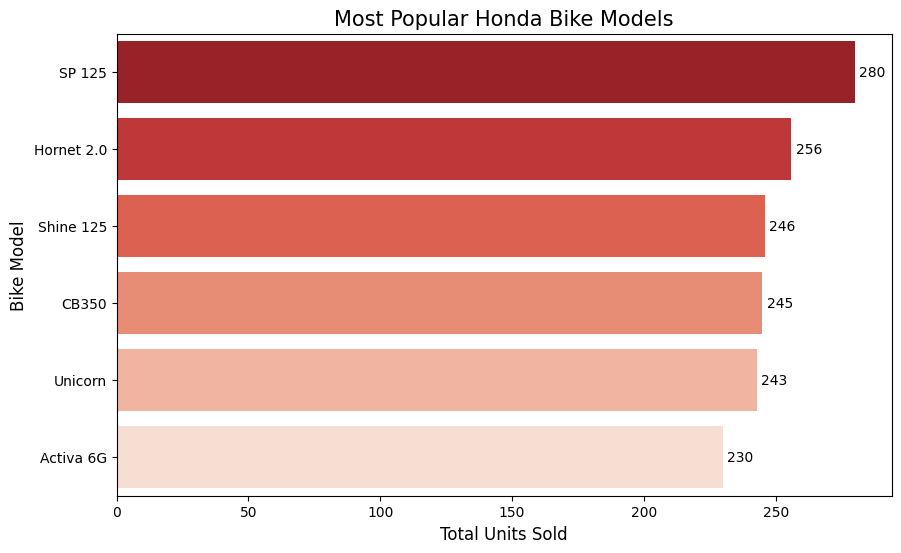

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the volume numbers using a nice red color palette
ax = sns.barplot(x=top_models_volume.values, y=top_models_volume.index, palette="Reds_r")

plt.title("Most Popular Honda Bike Models", fontsize=15)
plt.xlabel("Total Units Sold", fontsize=12)
plt.ylabel("Bike Model", fontsize=12)

# Add numeric labels to the end of the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()


# Sales_Channel Analsis

In [9]:
prefer_Sales_Channel=df['Sales_Channel'].value_counts()
print(prefer_Sales_Channel)

Sales_Channel
Corporate Sale      504
Online Booking      504
Showroom Walk-in    492
Name: count, dtype: int64


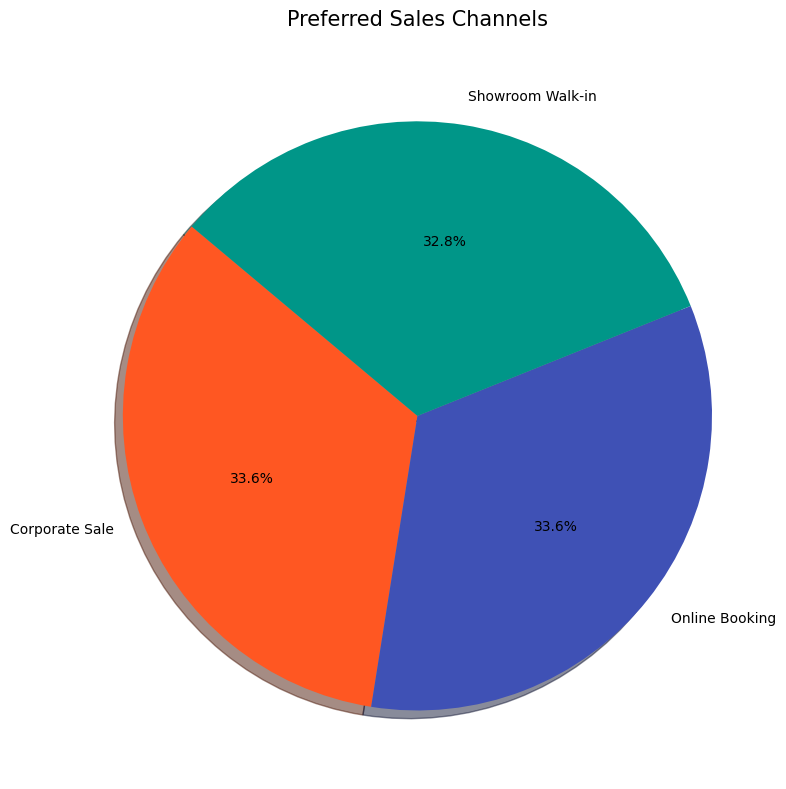

In [10]:
plt.figure(figsize=(8, 8))

# Defining the explosion offset (we use the index length to calculate how many slices to pull out)
explode_effect = [0.05] * len(prefer_Sales_Channel) 

# Plotting the pie chart
plt.pie(prefer_Sales_Channel, 
        labels=prefer_Sales_Channel.index,   # The names of the sales channels
        autopct='%1.1f%%',                   # Automatically calculates and formats percentages
        startangle=140, 
        colors=['#FF5722', '#3F51B5', '#009688', '#FFC107', '#E91E63'][:len(prefer_Sales_Channel)], 
        shadow=True)

# Adding a clean title
plt.title('Preferred Sales Channels', fontsize=15, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a perfect circle.

# Show the plot
plt.tight_layout()
plt.show()


# Gender-wise purchases Analysis

In [11]:

# Analysis of Gender-wise purchases
gender_purchases = df['Customer_Gender'].value_counts()
print("Gender-wise Purchase Counts:")
print(gender_purchases)

total_costomer= df[df['Customer_Gender'].isin(['Male', 'Female'])]['Customer_Gender'].count()
print(f"total_costomer=",total_costomer)







Gender-wise Purchase Counts:
Customer_Gender
Female    773
Male      727
Name: count, dtype: int64
total_costomer= 1500


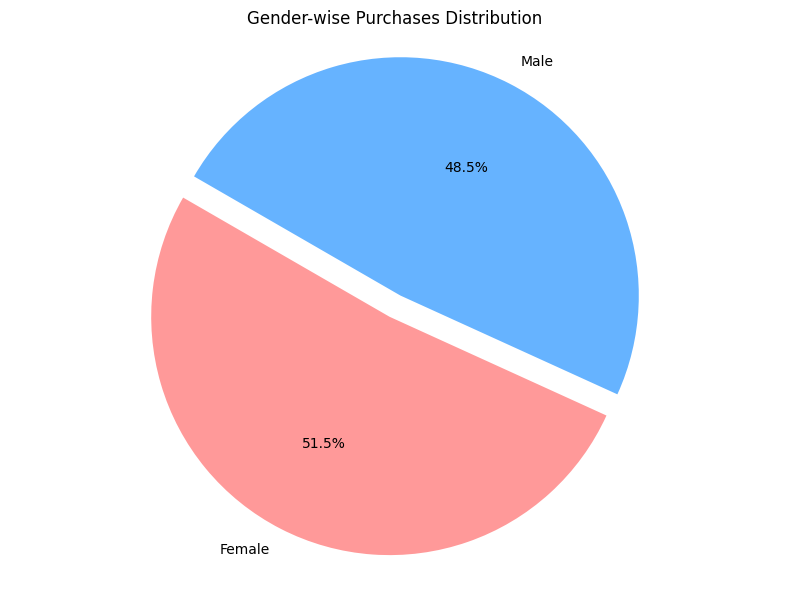

In [12]:

# Pie chart visualization
plt.figure(figsize=(8, 6))

# Plotting the pie chart
plt.pie(gender_purchases, 
        labels=gender_purchases.index, 
        autopct='%1.1f%%', 
        colors=[ '#ff9999','#66b3ff', '#99ff99'], 
        startangle=150, 
        explode=[0.05] * len(gender_purchases) # slightly pull out slices
        ) 

plt.title('Gender-wise Purchases Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()
plt.show()

# Analysis Preferred payment methods

In [13]:
import pandas as pd

# Calculate the frequency of each payment method
payment_methods = df['Payment_Mode'].value_counts()

print("Preferred Payment Methods by costomer:")
print(payment_methods)


Preferred Payment Methods by costomer:
Payment_Mode
Cash           417
Credit Card    379
UPI            366
Finance        338
Name: count, dtype: int64


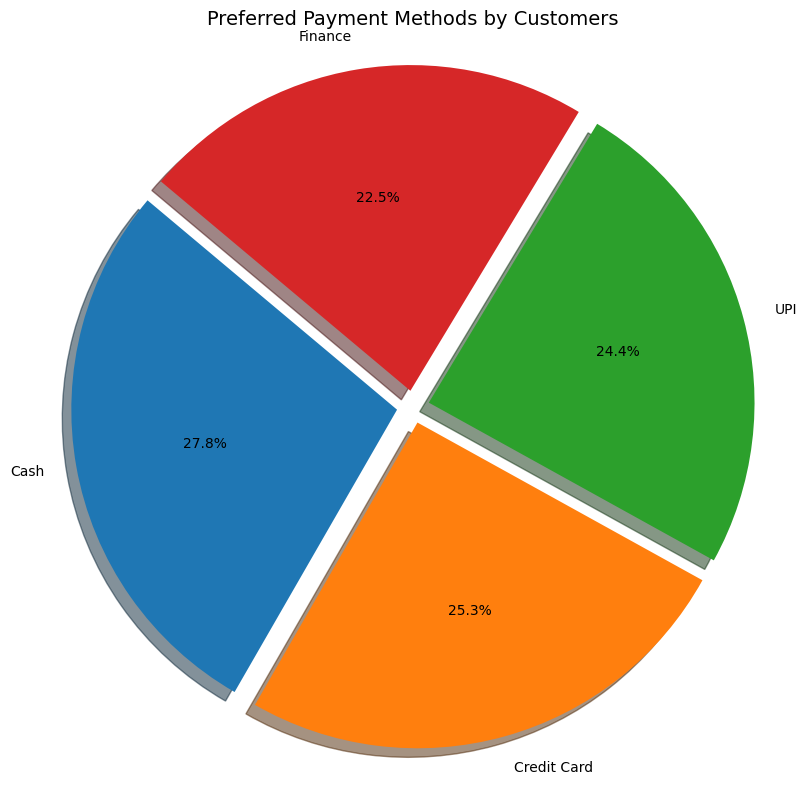

In [14]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 8))

# Define an explosion array to slightly separate the slices (adjusting based on how many methods there are)
explode_effect = [0.05] * len(payment_methods) 

plt.pie(payment_methods, 
        labels=payment_methods.index, 
        autopct='%1.1f%%', 
        startangle=140,
        explode=explode_effect,
        shadow=True)

plt.title('Preferred Payment Methods by Customers', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()
plt.show()


# ＃Relation between Delivery days vs customer rating

In [15]:
import pandas as pd



# removing missing values in these columns
analysis_df = df[['Delivery_Days', 'Customer_Rating']].dropna()

# 1. Calculate Average Custom Rating for each Delivery Day
avg_rating_per_day = analysis_df.groupby('Delivery_Days')['Customer_Rating'].mean().reset_index()
print("Average Customer Rating by Delivery Days:")
print(avg_rating_per_day)

print('🌟Conclusion: Delivery days do not seem to negatively impact customer ratings significantly.')


Average Customer Rating by Delivery Days:
    Delivery_Days  Customer_Rating
0               1         4.213889
1               2         4.216049
2               3         4.314000
3               4         4.238889
4               5         4.294595
5               6         4.218391
6               7         4.323000
7               8         4.228421
8               9         4.294624
9              10         4.234951
10             11         4.285714
11             12         4.323585
12             13         4.253922
13             14         4.200000
14             15         4.280000
🌟Conclusion: Delivery days do not seem to negatively impact customer ratings significantly.


# Age distribution of costomer 

we can use this data for tagated add for the age grouop.

In [16]:
import pandas as pd

# drop any missing values to prevent errors
age_data = df['Customer_Age'].dropna()

# Define the age "bins" (e.g., ages 18-25, 26-35, 36-45...)
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

# Create a new column categorizing each customer into their respective age group
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=True)

# Count how many customers fall into each age group
age_distribution = df['Age_Group'].value_counts().sort_index()

print("Customer Age Distribution (Market Size by Group):")
print(age_distribution)

# Identify the largest market
largest_group = age_distribution.idxmax()
print(f"\n--> The largest market is the '{largest_group}' age group, with {age_distribution.max()} customers.")


Customer Age Distribution (Market Size by Group):
Age_Group
18-25    246
26-35    422
36-45    420
46-55    412
56-65      0
65+        0
Name: count, dtype: int64

--> The largest market is the '26-35' age group, with 422 customers.


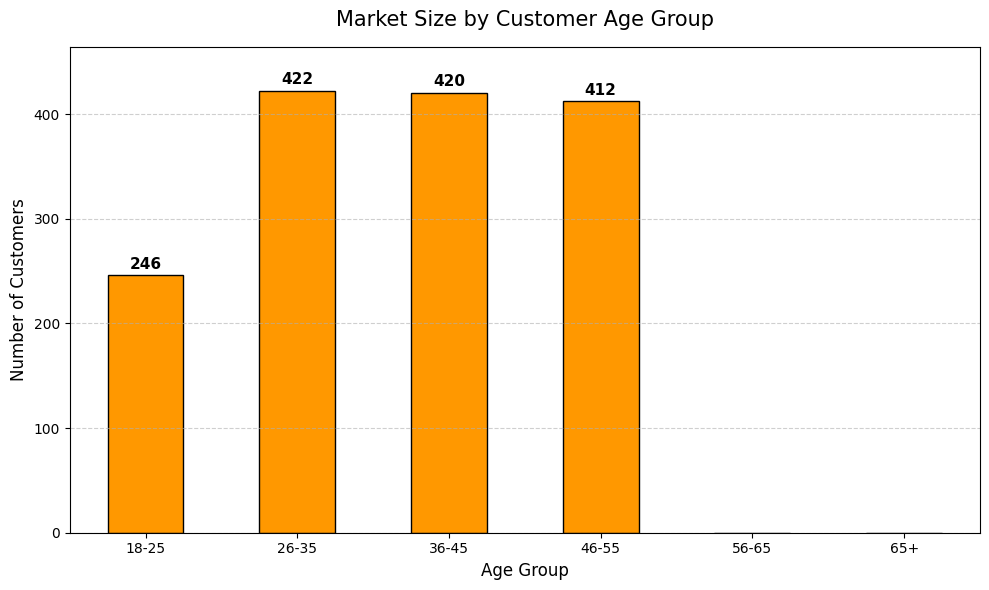

In [17]:
from matplotlib.pyplot import margins
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

#-----------------------------------------
ax = age_distribution.plot(
    kind='bar', 
    color='#FF9800', 
    edgecolor='black'
)

# 2. Add the exact numbers on top of each bar
for p in ax.patches:
    # get_height() gets the exact number for that bar
    value = int(p.get_height()) 
    
    # Only write the number if it's greater than 0
    if value > 0:
        ax.annotate(str(value), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), # Position (center x, top y)
                    ha='center', va='center', 
                    xytext=(0, 8),          # Shift the text 8 points up
                    textcoords='offset points',
                    fontsize=11, fontweight='bold', color='black')

# Adding titles and labels
plt.title('Market Size by Customer Age Group', fontsize=15, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Make the x-axis labels horizontal and clear
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 3. Slightly increase the very top of the y-axis so the numbers don't get cut off
plt.ylim(0, age_distribution.max() * 1.1)

plt.tight_layout()
plt.show()


# Analysis of which age group gives the maximum total profit.

In [18]:
import pandas as pd

# Group by the Age_Group column and calculate the sum of Gross_Profit
age_profit = df.groupby('Age_Group')['Gross_Profit'].sum()

# Sort the values from highest profit to lowest
age_profit_sorted = age_profit.sort_values(ascending=False)

print("Total Profit Generated by Each Age Group:")
print(age_profit_sorted.apply(lambda x: f"₹ {x:,.2f}"))  # Formatted as currency

# Identify the most profitable group
max_profit_group = age_profit_sorted.idxmax()
print(f"\n--> The '{max_profit_group}' age group gives the maximum profit!")


Total Profit Generated by Each Age Group:
Age_Group
46-55    ₹ 12,565,097.00
26-35    ₹ 12,559,499.00
36-45    ₹ 12,430,677.00
18-25     ₹ 7,191,187.00
Name: Gross_Profit, dtype: str

--> The '46-55' age group gives the maximum profit!


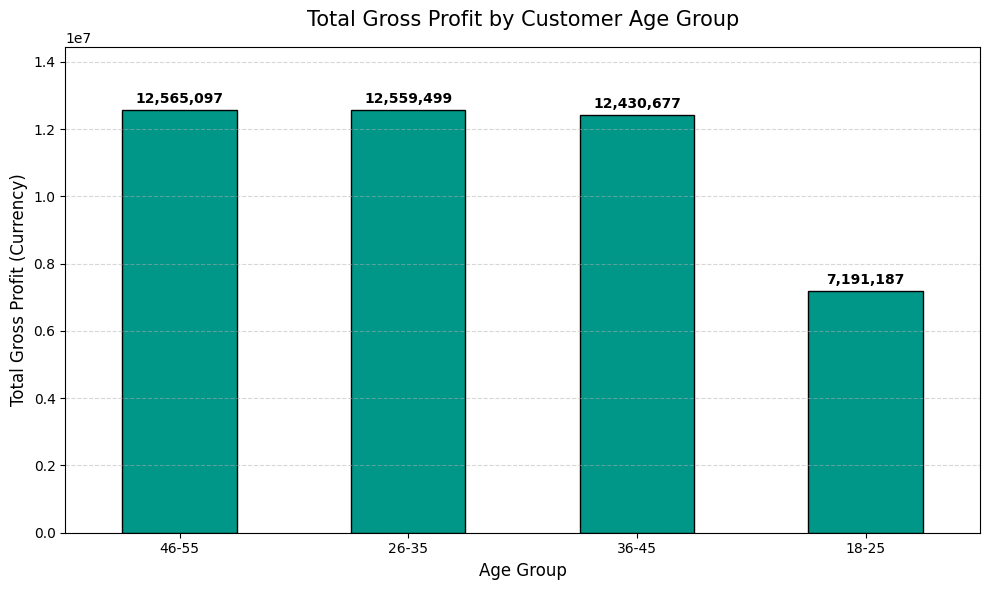

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the bar chart
ax = age_profit_sorted.plot(
    kind='bar', 
    color='#009688',  # A nice green color to represent profit
    edgecolor='black'
)

# Add exact numbers above each bar
for p in ax.patches:
    value = p.get_height()
    
    if value > 0:
        # Formats the number down to the thousand/million if needed, or just prints raw value
        ax.annotate(f"{int(value):,}",  # The comma formatting adds commas for readability (e.g. 1,000,000)
                    (p.get_x() + p.get_width() / 2., value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='black')

# Adding titles and labels
plt.title('Total Gross Profit by Customer Age Group', fontsize=15, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Gross Profit (Currency)', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Keep the top margin clear for the text annotations
plt.ylim(0, age_profit_sorted.max() * 1.15)

plt.tight_layout()
plt.show()


#  Gross Profit by Dealer Name📊
This plot will allow us to compare the profitability across different dealers. (very high or very low profit sales).

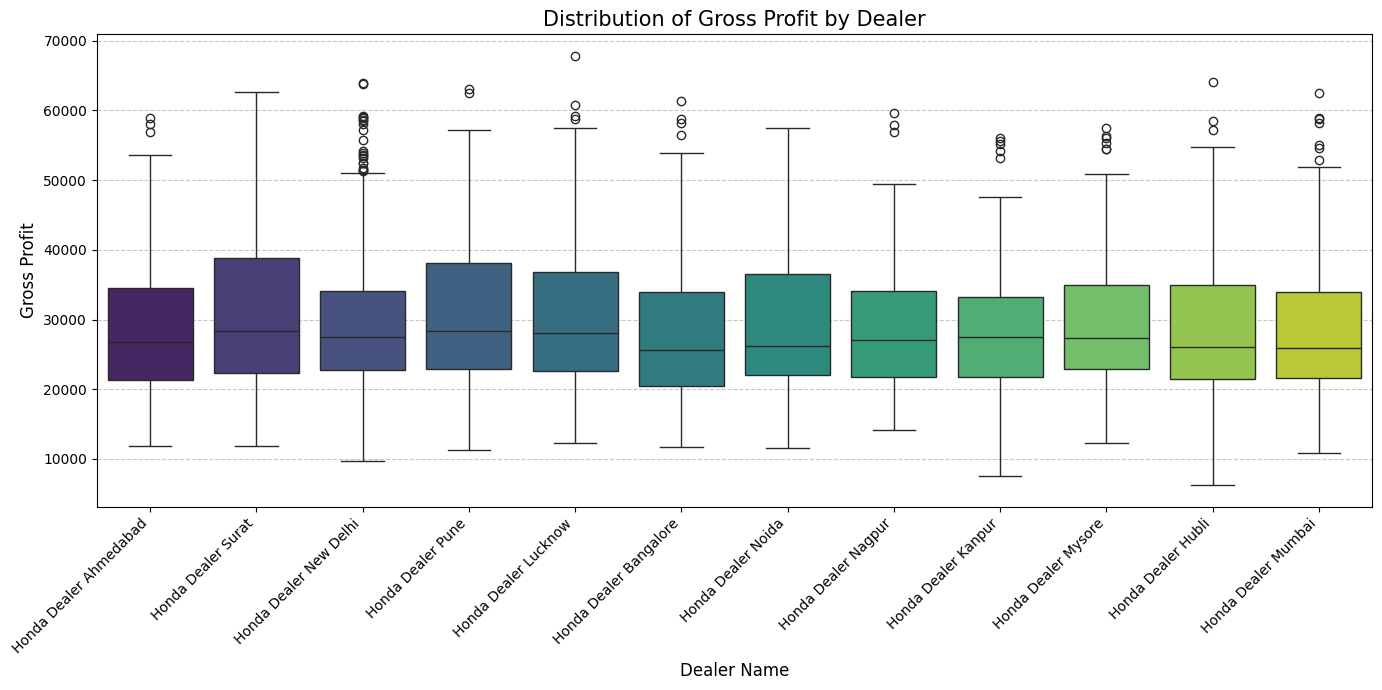

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Create the box plot
sns.boxplot(data=df, x='Dealer_Name', y='Gross_Profit', hue='Dealer_Name', palette='viridis', legend=False)

# Add titles and labels
plt.title('Distribution of Gross Profit by Dealer', fontsize=15)
plt.xlabel('Dealer Name', fontsize=12)
plt.ylabel('Gross Profit', fontsize=12)

# Rotate the dealer names so they are readable
plt.xticks(rotation=45, ha='right')

# Add a subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


#  Customer Ratings by Dealer⭐️⭐️⭐️⭐️⭐️
(This highlights which dealers consistently perform well and which have a wide variance in customer satisfaction).

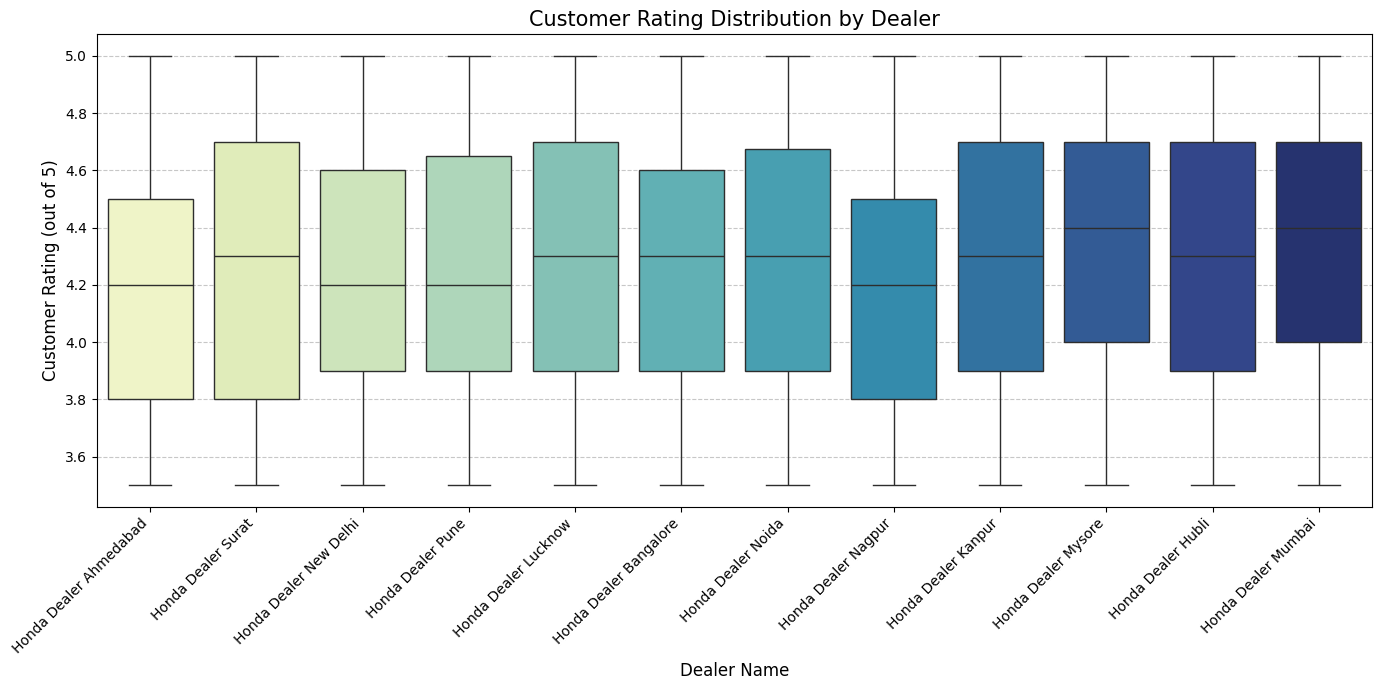

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Dealer_Name', y='Customer_Rating', hue='Dealer_Name', palette='YlGnBu', legend=False)
plt.title('Customer Rating Distribution by Dealer', fontsize=15)
plt.xlabel('Dealer Name', fontsize=12)
plt.ylabel('Customer Rating (out of 5)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Total sales of Year / Month

In [3]:
# Group by year and sum the sales amount
yearly_revenue = df.groupby('Year')['Net_Sales_Amount'].sum()

# Convert the raw numbers into formatted 'Rs' strings with commas
formatted_revenue = yearly_revenue.map('Rs {:,.0f}'.format)

print("Total Sales Revenue by Year:")
print(formatted_revenue)

print("\n--------------------------\n")

# 2. Total Volume (Number of Cars/Bikes) sold per year
yearly_volume = df.groupby('Year').size() 
print("Total number of Vehicles Sold by Year:")
print(yearly_volume)


Total Sales Revenue by Year:
Year
2025    Rs 96,260,457
2026    Rs 91,315,902
Name: Net_Sales_Amount, dtype: str

--------------------------

Total number of Vehicles Sold by Year:
Year
2025    766
2026    734
dtype: int64


/var/folders/0r/9j0gh7hn71b7h91lvbs75b300000gp/T/ipykernel_9180/3918079523.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yearly_revenue.index, y=yearly_revenue.values, palette="viridis")


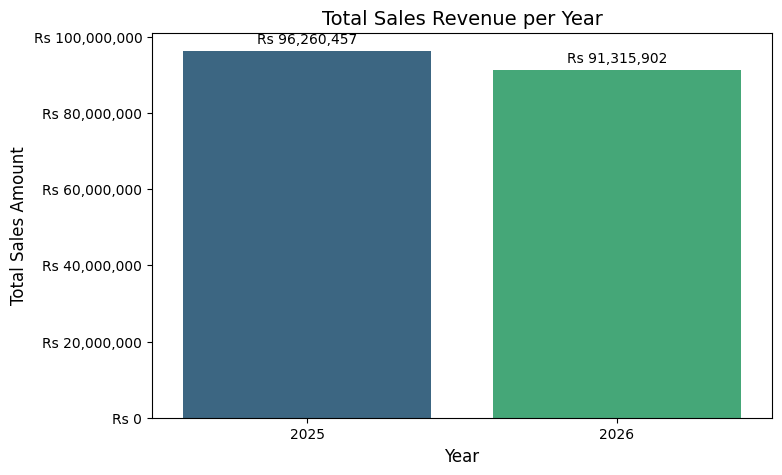

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8, 5))

# Plot the bar chart and save it into a variable called 'ax'
ax = sns.barplot(x=yearly_revenue.index, y=yearly_revenue.values, palette="viridis")

# 1. Create a quick function to format numbers with 'Rs' and commas
def as_rupees(x, pos):
    return f"Rs {x:,.0f}"

# Apply that formatting to the numbers on the left (Y-axis)
ax.yaxis.set_major_formatter(FuncFormatter(as_rupees))

# 2. Add the custom formatted data labels on top of the bars
for container in ax.containers:
    # We calculate the height of each bar, run it through our format string, 
    # and pass the list of those formatted strings into the label function
    labels = [f"Rs {v.get_height():,.0f}" for v in container]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Total Sales Revenue per Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales Amount", fontsize=12)

plt.show()


# Sales analysis State / City wise 

In [5]:
# Group by both State and City, sum the sales, and sort from highest to lowest
state_city_sales = df.groupby(['State', 'City'])['Net_Sales_Amount'].sum().sort_values(ascending=False)

# Apply our 'Rs' and comma formatting
formatted_city_sales = state_city_sales.map('Rs {:,.0f}'.format)

# Print the top 15 highest selling cities (or remove .head(15) to see all of them)
print("Top 15 Selling Cities:")
print(formatted_city_sales.head(15))


Top 15 Selling Cities:
State          City     
Delhi          New Delhi    Rs 37,058,110
Gujarat        Ahmedabad    Rs 19,184,650
               Surat        Rs 18,439,146
Uttar Pradesh  Lucknow      Rs 16,004,261
Maharashtra    Mumbai       Rs 13,905,802
Uttar Pradesh  Noida        Rs 13,787,697
Karnataka      Bangalore    Rs 13,343,024
Uttar Pradesh  Kanpur       Rs 12,055,916
Karnataka      Hubli        Rs 11,837,689
               Mysore       Rs 11,491,182
Maharashtra    Pune         Rs 11,224,433
               Nagpur        Rs 9,244,449
Name: Net_Sales_Amount, dtype: str


/var/folders/0r/9j0gh7hn71b7h91lvbs75b300000gp/T/ipykernel_9180/3347082922.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_cities.values, y=city_labels, palette="magma")


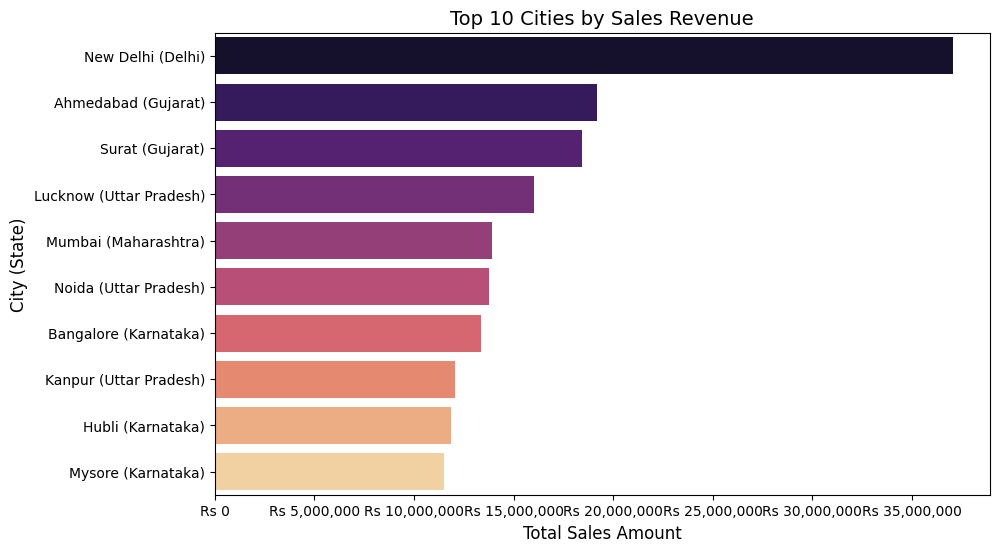

In [6]:
from matplotlib.ticker import FuncFormatter

# Grab just the top 10 cities
top_10_cities = state_city_sales.head(10)

plt.figure(figsize=(10, 6))

# For the Y-axis names, we combine the City and the State (e.g., 'Pune (Maharashtra)')
city_labels = [f"{city} ({state})" for state, city in top_10_cities.index]

# Plot a horizontal bar chart
ax = sns.barplot(x=top_10_cities.values, y=city_labels, palette="magma")

plt.title("Top 10 Cities by Sales Revenue", fontsize=14)
plt.xlabel("Total Sales Amount", fontsize=12)
plt.ylabel("City (State)", fontsize=12)

# Format the X-axis bottom numbers with our 'Rs' currency format
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"Rs {x:,.0f}"))

plt.show()



# Monthly sales analysis of each state over a year

In [7]:
import calendar

# Create a pivot table. 
# We use 'MonthIndex' (1-12) for columns so they automatically sort chronologicaly!
state_month_table = pd.pivot_table(
    df,
    values='Net_Sales_Amount',
    index='State',
    columns='MonthIndex',
    aggfunc='sum',
    fill_value=0 # If a state had no sales in a month, fill it with 0 instead of NaN
)

# Rename the 1-12 column headers to actual month abbreviations (Jan, Feb, Mar...)
month_names = {i: calendar.month_abbr[i] for i in range(1, 13)}
state_month_table = state_month_table.rename(columns=month_names)

# Apply our Rs formatting to make it readable
formatted_pivot_table = state_month_table.map('Rs {:,.0f}'.format)

print("Sales Revenue by State and Month:")
# If Jupyter cuts off the table, use display(formatted_pivot_table) instead of print()
display(formatted_pivot_table)


Sales Revenue by State and Month:


MonthIndex,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
State,,,,,,,,,,,,
Delhi,"Rs 3,152,734","Rs 2,660,113","Rs 3,351,500","Rs 3,570,829","Rs 1,804,490","Rs 2,394,620","Rs 3,195,993","Rs 2,953,331","Rs 3,073,383","Rs 3,793,354","Rs 2,713,919","Rs 4,393,844"
Gujarat,"Rs 3,334,984","Rs 3,321,128","Rs 2,251,777","Rs 2,463,011","Rs 3,536,135","Rs 3,660,801","Rs 2,856,704","Rs 4,040,385","Rs 3,023,877","Rs 2,010,761","Rs 3,966,255","Rs 3,157,978"
Karnataka,"Rs 3,142,533","Rs 3,298,586","Rs 4,076,747","Rs 3,877,267","Rs 3,618,596","Rs 1,643,491","Rs 2,751,848","Rs 2,703,567","Rs 3,497,089","Rs 2,491,600","Rs 3,190,904","Rs 2,379,667"
Maharashtra,"Rs 2,547,625","Rs 2,047,239","Rs 2,376,036","Rs 2,682,777","Rs 3,289,291","Rs 2,780,804","Rs 2,724,097","Rs 2,803,568","Rs 3,326,989","Rs 2,671,054","Rs 3,122,902","Rs 4,002,302"
Uttar Pradesh,"Rs 2,623,771","Rs 2,992,382","Rs 3,845,912","Rs 4,632,128","Rs 3,206,601","Rs 4,884,279","Rs 3,936,373","Rs 3,555,002","Rs 2,545,587","Rs 4,255,757","Rs 2,852,492","Rs 2,517,590"


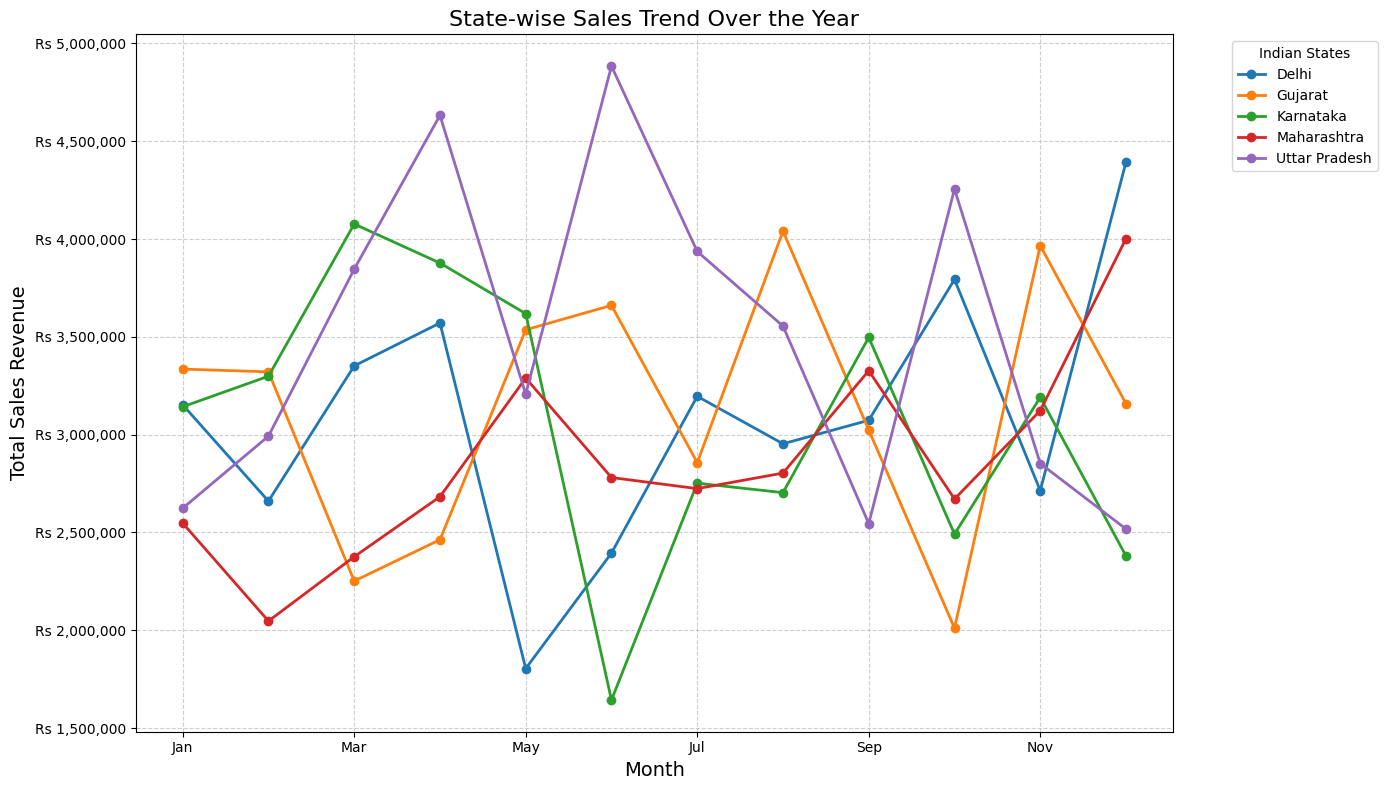

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Make the chart nice and wide
plt.figure(figsize=(14, 8))

# .T transposes our table so Months become the X-axis
# marker='o' adds little dots at each data point so it's easier to read
ax = state_month_table.T.plot(ax=plt.gca(), marker='o', linewidth=2) 

plt.title("State-wise Sales Trend Over the Year", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Total Sales Revenue", fontsize=14)

# Apply our 'Rs' formatter to the Y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"Rs {x:,.0f}"))

# Add a subtle grid behind the lines so it's easier to match lines to Y-axis numbers
plt.grid(True, linestyle='--', alpha=0.6)

# Because there are many states, the legend block might cover up the lines! 
# This command moves the legend box nicely outside the chart to the right
plt.legend(title='Indian States', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Snaps everything neatly into the figure window

plt.show()




# Average Monthly Sales (Top 10 Cities)

In [9]:
# 1. Calculate the *Total* Sales for each City during each individual month
city_monthly_totals = df.groupby(['City', 'MonthIndex'])['Net_Sales_Amount'].sum()

# 2. Group those sums back by City, and find the *Average* of those monthly totals
avg_monthly_revenue = city_monthly_totals.groupby('City').mean().sort_values(ascending=False)

# 3. Format with the Rs symbol and commas
formatted_avg = avg_monthly_revenue.map('Rs {:,.0f}'.format)

print("Average Monthly Sales Revenue by City:")
print(formatted_avg.head(15)) # Showing the Top 15, remove .head() to print all


Average Monthly Sales Revenue by City:
City
New Delhi    Rs 3,088,176
Ahmedabad    Rs 1,598,721
Surat        Rs 1,536,596
Lucknow      Rs 1,333,688
Mumbai       Rs 1,158,817
Noida        Rs 1,148,975
Bangalore    Rs 1,111,919
Kanpur       Rs 1,004,660
Hubli          Rs 986,474
Mysore         Rs 957,598
Pune           Rs 935,369
Nagpur         Rs 770,371
Name: Net_Sales_Amount, dtype: str


/var/folders/0r/9j0gh7hn71b7h91lvbs75b300000gp/T/ipykernel_9180/3986973881.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_avg.values, y=top_10_avg.index, palette="mako")


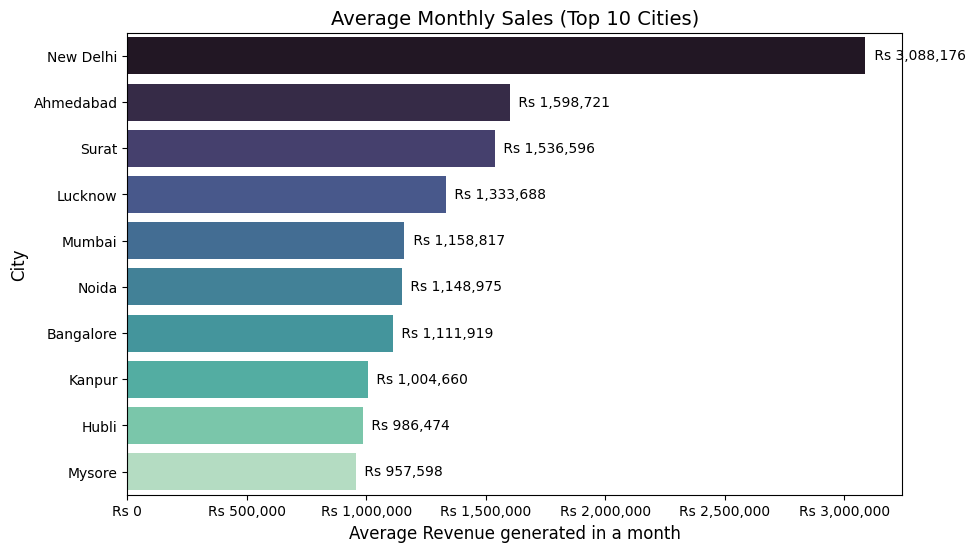

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Grab the top 10 cities for the chart
top_10_avg = avg_monthly_revenue.head(10)

plt.figure(figsize=(10, 6))

# Horizontal bar chart
ax = sns.barplot(x=top_10_avg.values, y=top_10_avg.index, palette="mako")

# Add the formatted data labels on the ends of the bars
for container in ax.containers:
    labels = [f" Rs {v.get_width():,.0f}" for v in container]
    ax.bar_label(container, labels=labels, padding=3)

plt.title("Average Monthly Sales (Top 10 Cities)", fontsize=14)
plt.xlabel("Average Revenue generated in a month", fontsize=12)
plt.ylabel("City", fontsize=12)

# Format the X-axis numbers
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"Rs {x:,.0f}"))

plt.show()


# On-Road Price by State 🛣️
This plot helps us to visualize how the on-road price of vehicles fluctuates across different states (which could be influenced by local taxes, registration fees, or varying demand).

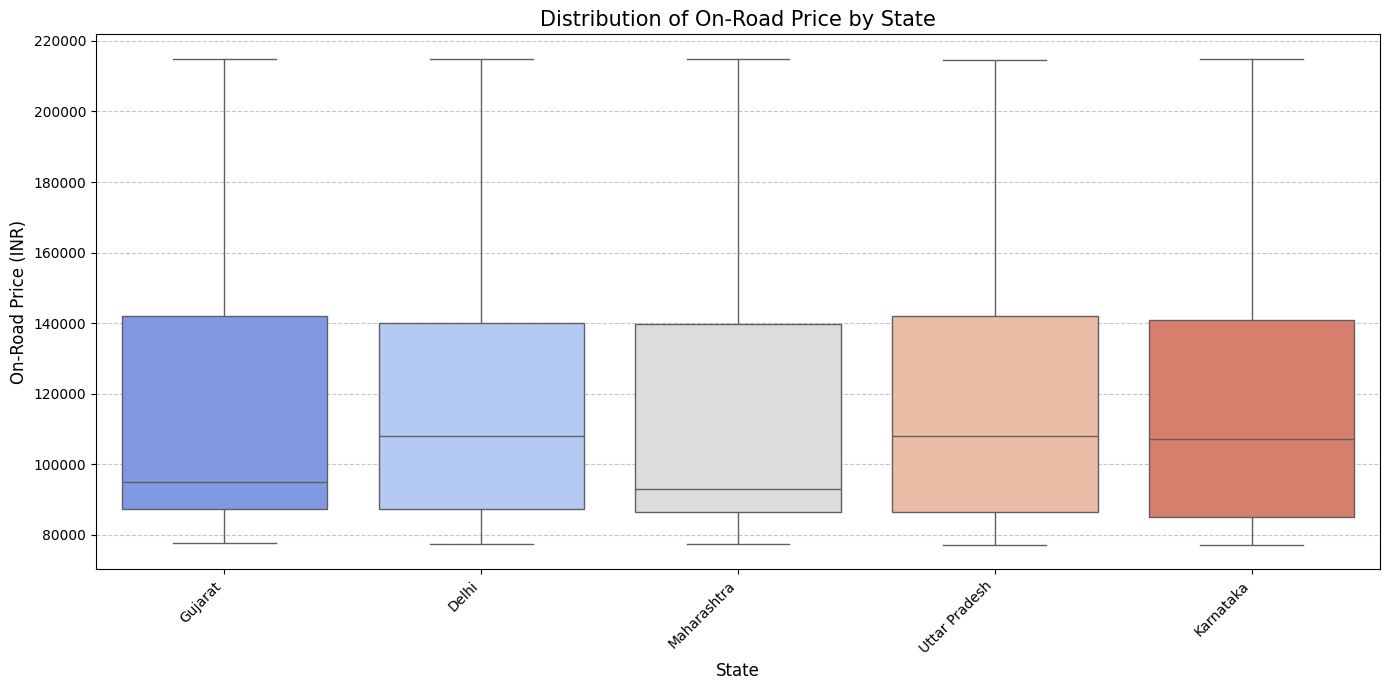

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Create the box plot
sns.boxplot(data=df, x='State', y='On_Road_Price', hue='State', palette='coolwarm', legend=False)

# Add titles and labels
plt.title('Distribution of On-Road Price by State', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('On-Road Price (INR)', fontsize=12)

# Rotate the state names so they are easily readable
plt.xticks(rotation=45, ha='right')

# Add a subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# % Calculate the Profit_Percent


In [3]:
df['Profit_Percent'] = ((df['Gross_Profit'] / df['Cost_Price']) * 100).round(2).astype(str) + '%'
df.head()


,Order_ID,Order_Date,Year,MonthIndex,Month,Quarter,State,City,Dealer_Name,Sales_Channel,...,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating,Profit_Percent
0,ORD00001,30-06-2026,2026,6,June,Q2,Gujarat,Ahmedabad,Honda Dealer Ahmedabad,Corporate Sale,...,3408,5959,89385,282,98752,70286,28466,10,3.7,40.5%
1,ORD00002,15-01-2025,2025,1,January,Q1,Gujarat,Surat,Honda Dealer Surat,Corporate Sale,...,6848,5632,71022,4372,83502,64631,18871,10,3.7,29.2%
2,ORD00003,20-07-2026,2026,7,July,Q3,Delhi,New Delhi,Honda Dealer New Delhi,Corporate Sale,...,3476,7948,86328,3323,97752,70208,27544,7,4.7,39.23%
3,ORD00004,06-05-2026,2026,5,May,Q2,Maharashtra,Pune,Honda Dealer Pune,Corporate Sale,...,3787,9562,0,2396,146429,117282,29147,5,4.9,24.85%
4,ORD00005,23-11-2025,2025,11,November,Q4,Uttar Pradesh,Lucknow,Honda Dealer Lucknow,Online Booking,...,6951,7719,86615,1289,101285,69400,31885,10,4.9,45.94%


# 📅 Convert Order_Date → datetime [formate]

In [4]:
import pandas as pd



# 1. Convert the 'Order_Date' column to datetime objects first
# (If it's already a datetime column, you can skip this step)
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# 2. Format it to "12-March-2026" (%d is day, %B is full month name, %Y is 4-digit year)
df['Order_Date'] = df['Order_Date'].dt.strftime('%d-%B-%Y').str.upper()



/var/folders/wr/58nvwg1d4tjc3n0sp220yp2m0000gp/T/ipykernel_30831/2856250559.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])


In [5]:
df.head()

,Order_ID,Order_Date,Year,MonthIndex,Month,Quarter,State,City,Dealer_Name,Sales_Channel,...,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating,Profit_Percent
0,ORD00001,30-JUNE-2026,2026,6,June,Q2,Gujarat,Ahmedabad,Honda Dealer Ahmedabad,Corporate Sale,...,3408,5959,89385,282,98752,70286,28466,10,3.7,40.5%
1,ORD00002,15-JANUARY-2025,2025,1,January,Q1,Gujarat,Surat,Honda Dealer Surat,Corporate Sale,...,6848,5632,71022,4372,83502,64631,18871,10,3.7,29.2%
2,ORD00003,20-JULY-2026,2026,7,July,Q3,Delhi,New Delhi,Honda Dealer New Delhi,Corporate Sale,...,3476,7948,86328,3323,97752,70208,27544,7,4.7,39.23%
3,ORD00004,06-MAY-2026,2026,5,May,Q2,Maharashtra,Pune,Honda Dealer Pune,Corporate Sale,...,3787,9562,0,2396,146429,117282,29147,5,4.9,24.85%
4,ORD00005,23-NOVEMBER-2025,2025,11,November,Q4,Uttar Pradesh,Lucknow,Honda Dealer Lucknow,Online Booking,...,6951,7719,86615,1289,101285,69400,31885,10,4.9,45.94%


# Removeing outliers is any 
•	Customer_Age → remove unrealistic values (like <18 or >80)


In [14]:
# Keep only rows where Customer_Age is >= 18 AND <= 80
df = df[(df['Customer_Age'] >= 18) & (df['Customer_Age'] <= 80)]

# Optional: Reset the index after dropping rows
# df = df.reset_index(drop=True)


In [15]:
df[(df['Customer_Age'] <= 18) | (df['Customer_Age'] >= 80)]['Customer_Age'].count()
# checking unrealistic Coustomer_Age




np.int64(0)

In [16]:
df[(df['Customer_Age'] <= 18) | (df['Customer_Age'] >= 80)]['Customer_Age'].count()
# checking unrealistic Coustomer_Age




np.int64(0)

In [19]:
df[(df['Customer_Age'] <= 18) | (df['Customer_Age'] >= 80)]['Customer_Age'].count()
# checking unrealistic Coustomer_Age

np.int64(0)

In [18]:
df.head()


,Order_ID,Order_Date,Year,MonthIndex,Month,Quarter,State,City,Dealer_Name,Sales_Channel,...,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating,Profit_Percent
0,ORD00001,30-JUNE-2026,2026,6,June,Q2,Gujarat,Ahmedabad,Honda Dealer Ahmedabad,Corporate Sale,...,3408,5959,89385,282,98752,70286,28466,10,3.7,40.5%
1,ORD00002,15-JANUARY-2025,2025,1,January,Q1,Gujarat,Surat,Honda Dealer Surat,Corporate Sale,...,6848,5632,71022,4372,83502,64631,18871,10,3.7,29.2%
2,ORD00003,20-JULY-2026,2026,7,July,Q3,Delhi,New Delhi,Honda Dealer New Delhi,Corporate Sale,...,3476,7948,86328,3323,97752,70208,27544,7,4.7,39.23%
3,ORD00004,06-MAY-2026,2026,5,May,Q2,Maharashtra,Pune,Honda Dealer Pune,Corporate Sale,...,3787,9562,0,2396,146429,117282,29147,5,4.9,24.85%
4,ORD00005,23-NOVEMBER-2025,2025,11,November,Q4,Uttar Pradesh,Lucknow,Honda Dealer Lucknow,Online Booking,...,6951,7719,86615,1289,101285,69400,31885,10,4.9,45.94%


# Customer_Gender → standardize (Male/Female only)

In [20]:

df[df['Customer_Gender'].isin(['Male', 'Female'])]['Customer_Gender'].count()



np.int64(1500)

# removing  extra spaces from Dealer_Name

In [22]:

df['Dealer_Name'] = df['Dealer_Name'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['Dealer_Name'].head()


0    Honda Dealer Ahmedabad
1        Honda Dealer Surat
2    Honda Dealer New Delhi
3         Honda Dealer Pune
4      Honda Dealer Lucknow
Name: Dealer_Name, dtype: str

In [23]:

df['Dealer_Name'] = df['Dealer_Name'].str.replace(r' ', '_', regex=True).str.strip()
df['City'] = df['City'].str.replace(r'\s+', ' ', regex=True)
df[['Dealer_Name', 'City']].head()


,Dealer_Name,City
0,Honda_Dealer_Ahmedabad,Ahmedabad
1,Honda_Dealer_Surat,Surat
2,Honda_Dealer_New_Delhi,New Delhi
3,Honda_Dealer_Pune,Pune
4,Honda_Dealer_Lucknow,Lucknow


# Force left-alignment for the City text

In [24]:
# Force left-alignment for the City text
df[['Dealer_Name', 'City']].head().style.set_properties(subset=['City'], **{'text-align': 'left'})


,Dealer_Name,City
0,Honda_Dealer_Ahmedabad,Ahmedabad
1,Honda_Dealer_Surat,Surat
2,Honda_Dealer_New_Delhi,New Delhi
3,Honda_Dealer_Pune,Pune
4,Honda_Dealer_Lucknow,Lucknow


# Delivery Days by State
 (This helps us to identify which states have fast deliveries and which suffer from logistical delays/outliers).

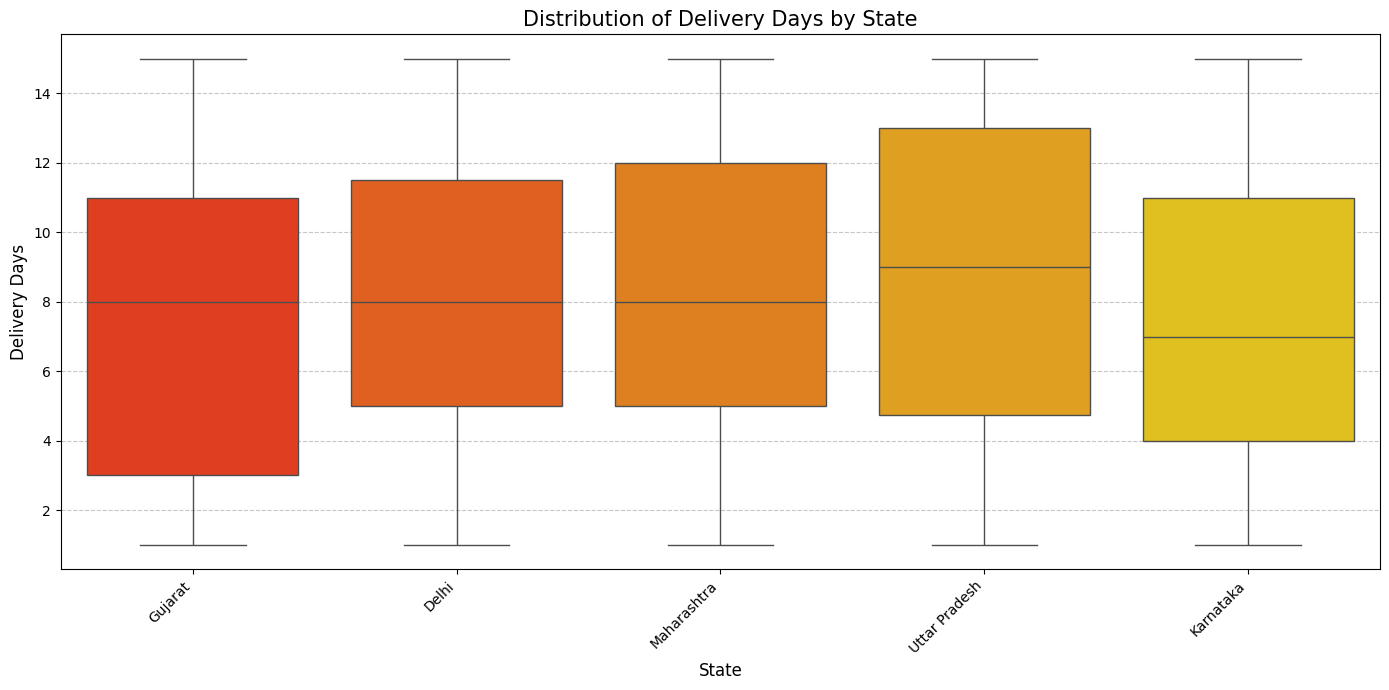

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='State', y='Delivery_Days', hue='State', palette='autumn', legend=False)
plt.title('Distribution of Delivery Days by State', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Delivery Days', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()